In [58]:
import os, re, glob
import yt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

yt.set_log_level(50)          # yt's INFO chatter drowns everything else

ROOT = "/home/pc08/Fernando/CLEMNew/PeleC-CLEM/Exec/RegTests/CrossJet"
AN   = ROOT + "/analysis"
OUT  = ROOT + "/ResultsNonReact"          # figures are written here

# ---------------------------------------------------------------- THE KNOB --
# Instant at which every closure is compared. All four cases must have reached
# it, so it is limited by the SHORTEST run - print_inventory() below tells you
# what is currently reachable.
#   1.8e-4  every closure, as soon as Smagorinsky passes 0.18 ms
#   4.0e-4  needs Smagorinsky AND a re-run of case (i), which stopped at 0.18 ms
TCMP = 1.8e-4                             # s

UINF, DJET, XJET = 9.30e4, 0.1, 4.2       # cm/s, cm, cm  (freestream, jet d, jet x)
INK, MUTED = "#1a1a1a", "#6b6b6b"

In [4]:
# ------------------------------------------------------------- THE CASES ---
# label, plotfile glob, colour, marker.  Colours are Okabe-Ito (colourblind
# safe); the order is FIXED - never let a case change colour between figures.
# The reference is the paper's digitised L2 data, always hollow black circles.
CASES = [
    ("(i) no SGS stress (do_les=0)", ROOT + "/runs/01-nonreacting-CLEM/plt[0-9]*",        "#0072B2", "o"),
    ("(ii) Smagorinsky, Cs=0.16",    OUT  + "/CLEM-Smagorinsky/plt_nrS*",                 "#D55E00", "s"),
    ("(iii) WALE",                   ROOT + "/runs/04-reacting-CLEM-WALE-nowallmodel/plt_WALE*", "#009E73", "^"),
    ("(iv) WALE + wall model",       OUT  + "/CLEM-WALE-WM/plt_nrWM*",                    "#CC79A7", "D"),
]
# NOTE on (iii): that run had clem.do_react=1, but it never ignited (maxT flat
# at ~1215 K, Y(H2O) ~ 2e-5 for all 0.94 ms), so below 0.4 ms it is a
# non-reacting field. Re-run it inert if it ever has to go in a paper.

p_ref = pd.read_csv(AN + "/presRefL2.csv")   # x [mm], Pressure [MPa]
v_ref = pd.read_csv(AN + "/BLVelRef.csv")    # x [mm], velocity [m/s]

# Probe definitions - deliberately NO axes objects in here: an axes stored in a
# module-level list binds to one figure, and every later loop silently redraws
# into that first figure instead of the new one.
PROBES = [
    (1.0,     "pressure", 1e-7, p_ref, "Pressure", "pressure [MPa]",
     "pressure along y = 1.0 cm, z = 0.25 cm"),
    (1.49999, "magvel",   1e-2, v_ref, "velocity", "|u| [m/s]",
     "velocity in the top-wall cell, z = 0.25 cm"),
]


def series(pat):
    """Sorted [(time, path)] for a case. Skips AMReX .old.<pid> renames, which
    are stale directories from a previous attempt, not data."""
    out = []
    for p in glob.glob(pat):
        if ".old." in p or not os.path.isfile(os.path.join(p, "Header")):
            continue
        h = open(os.path.join(p, "Header")).read().split("\n")
        out.append((float(h[2 + int(h[1]) + 1]), p))   # ncomp names then time
    return sorted(out)


def at_time(pat, t, tol=6e-6):
    """Plotfile nearest t, or (None, None) if that case has not reached it.
    Returning None instead of the last available file keeps a short run from
    quietly entering a comparison at the wrong instant."""
    s = series(pat)
    if not s:
        return None, None
    tt, p = min(s, key=lambda r: abs(r[0] - t))
    return (tt, p) if abs(tt - t) <= tol else (None, None)


def ray_x(ds, y, z, field, scale=1.0):
    """Field along an x-parallel line, sorted in x. x in cm."""
    r = ds.ortho_ray(0, (y, z))
    x = np.array(r["x"])
    f = np.array(r[field]) * scale
    i = np.argsort(x)
    return x[i], f[i]


def cgrid(ds):
    """Level-0 uniform arrays + cell size. Single level (CLEM is level-0 only),
    so a covering grid is exact, not an interpolation."""
    cg = ds.covering_grid(0, ds.domain_left_edge, ds.domain_dimensions)
    g = lambda f: np.array(cg["boxlib", f], dtype=np.float64)
    return g, np.array(ds.domain_width / ds.domain_dimensions, dtype=np.float64)


def qcrit(u, v, w, dx):
    """Q = 0.5(|Omega|^2 - |S|^2). Positive where rotation beats strain."""
    J = [[np.gradient(f, dx[b], axis=b, edge_order=2) for b in range(3)] for f in (u, v, w)]
    S = [[0.5 * (J[a][b] + J[b][a]) for b in range(3)] for a in range(3)]
    O = [[0.5 * (J[a][b] - J[b][a]) for b in range(3)] for a in range(3)]
    return 0.5 * (sum(O[a][b] ** 2 for a in range(3) for b in range(3))
                  - sum(S[a][b] ** 2 for a in range(3) for b in range(3)))


def style(ax, xl, yl, title):
    ax.set_xlabel(xl, fontsize=9, color=INK)
    ax.set_ylabel(yl, fontsize=9, color=INK)
    ax.set_title(title, loc="left", fontsize=10.5, color=INK)
    ax.grid(color="#ededed", lw=0.7)
    ax.tick_params(colors=MUTED, labelsize=8, length=3)
    for s in ax.spines.values():
        s.set_color("#cccccc")


def print_inventory():
    """What exists right now, and what TCMP is therefore allowed to be."""
    print(f"{'case':<32}{'n':>4}{'t_max [ms]':>12}   at TCMP = {TCMP*1e3:.3f} ms")
    print("-" * 74)
    tmax = []
    for lab, pat, _, _ in CASES:
        s = series(pat)
        if not s:
            print(f"{lab:<32}{0:>4}{'-':>12}   NO DATA")
            tmax.append(0.0); continue
        t, p = at_time(pat, TCMP)
        tmax.append(s[-1][0])
        ok = f"OK  {os.path.basename(p)}" if p else "NOT REACHED YET"
        print(f"{lab:<32}{len(s):>4}{s[-1][0]*1e3:>12.3f}   {ok}")
    print("-" * 74)
    print(f"largest instant all four share: {min(tmax)*1e3:.3f} ms")


print_inventory()

case                               n  t_max [ms]   at TCMP = 0.180 ms
--------------------------------------------------------------------------
(i) no SGS stress (do_les=0)      19       0.180   OK  plt14992
(ii) Smagorinsky, Cs=0.16         10       0.090   NOT REACHED YET
(iii) WALE                        95       0.940   OK  plt_WALE14920
(iv) WALE + wall model            41       0.400   OK  plt_nrWM15924
--------------------------------------------------------------------------
largest instant all four share: 0.090 ms


yt : [INFO     ] 2026-08-04 07:00:45,404 xlim = 0.000000 12.500000
yt : [INFO     ] 2026-08-04 07:00:45,405 ylim = 0.000000 1.500000
yt : [INFO     ] 2026-08-04 07:00:45,408 xlim = 0.000000 12.500000
yt : [INFO     ] 2026-08-04 07:00:45,408 ylim = 0.000000 1.500000
yt : [INFO     ] 2026-08-04 07:00:45,411 Making a fixed resolution buffer of (('gas', 'density')) 800 by 800



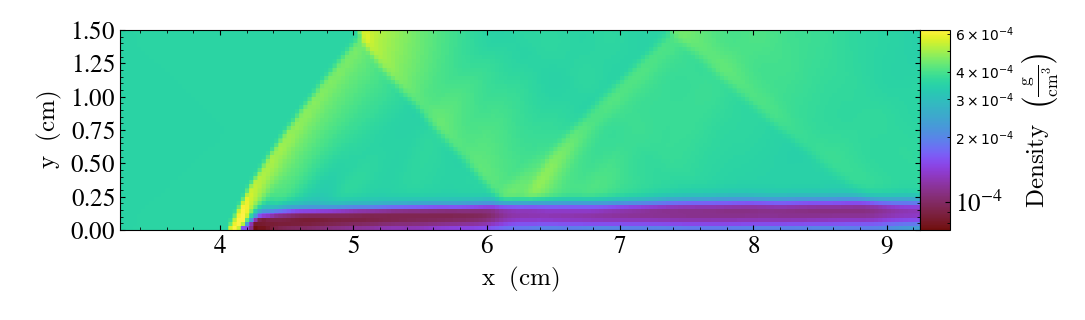

In [92]:
ds = yt.load("plt14165")
slc = yt.SlicePlot(ds, "z", ("density"), origin="native", center =[6.25, 0.75, 0.25])
slc.set_width(6.0, 1.5)
#slc.pan(())
slc.show()

PRESSURE FIELD AT THE CENTER OF THE CHANNEL

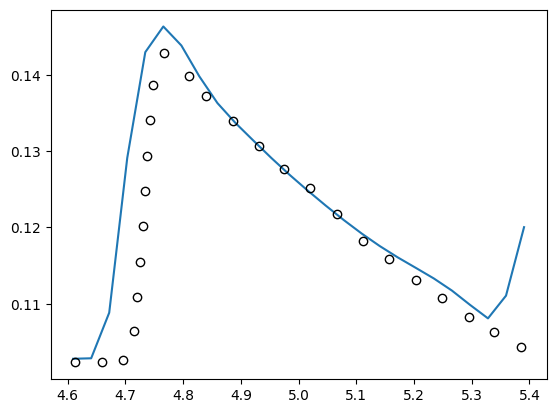

In [107]:
ray = ds.ortho_ray(0, (1.0, 0.25))   # axis 0 = x; coords are (y, z)
p_ref = pd.read_csv("presRefL2.csv")

# sort by x so the line plots cleanly
srt = np.argsort(ray["x"])
x = np.array(ray["x"])
p = np.array(ray["pressure"]/1e7)
srt = np.argsort(x)
x, p = x[srt], p[srt]

m = (x >= 4.6) & (x <= 5.4)
plt.plot(x[m], p[m])
plt.plot(p_ref["x"]/10, p_ref["Pressure"], linestyle ="",
         marker="o", markevery=3,
         markerfacecolor="none",      # hollow markers
         markeredgecolor="black",
         color="black")

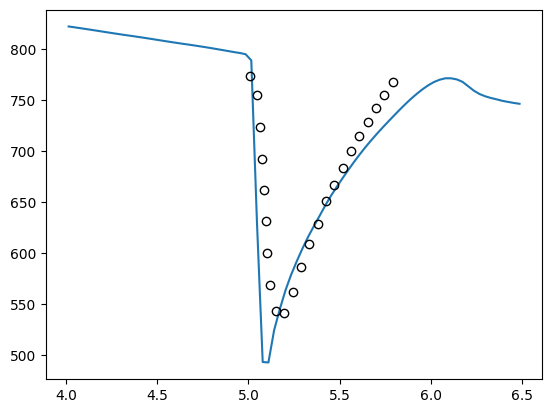

In [94]:
# sort by x so the line plots cleanly
ray = ds.ortho_ray(0, (1.49999, 0.25)) 
srt = np.argsort(ray["x"])
v_ref = pd.read_csv("BLVelRef.csv")


x = np.array(ray["x"])
p = np.array(ray["magvel"]/100)
srt = np.argsort(x)
x, p = x[srt], p[srt]

m = (x >= 4.0) & (x <= 6.5)
plt.plot(x[m], p[m])
plt.plot(v_ref["x"]/10, v_ref["velocity"], linestyle ="",
         marker="o", markevery=3,
         markerfacecolor="none",      # hollow markers
         markeredgecolor="black",
         color="black")

yt : [INFO     ] 2026-08-04 07:04:52,901 Parameters: current_time              = 8.000019628851029e-05
yt : [INFO     ] 2026-08-04 07:04:52,901 Parameters: domain_dimensions         = [400  48  16]
yt : [INFO     ] 2026-08-04 07:04:52,902 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2026-08-04 07:04:52,902 Parameters: domain_right_edge         = [12.5  1.5  0.5]
yt : [INFO     ] 2026-08-04 07:04:53,371 Parameters: current_time              = 0.00011000186336491491
yt : [INFO     ] 2026-08-04 07:04:53,371 Parameters: domain_dimensions         = [400  48  16]
yt : [INFO     ] 2026-08-04 07:04:53,372 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2026-08-04 07:04:53,373 Parameters: domain_right_edge         = [12.5  1.5  0.5]
yt : [INFO     ] 2026-08-04 07:04:53,721 Parameters: current_time              = 0.00014000568697791006
yt : [INFO     ] 2026-08-04 07:04:53,722 Parameters: domain_dimensions         = [400  48  16]
yt : [INFO     ] 2026-08

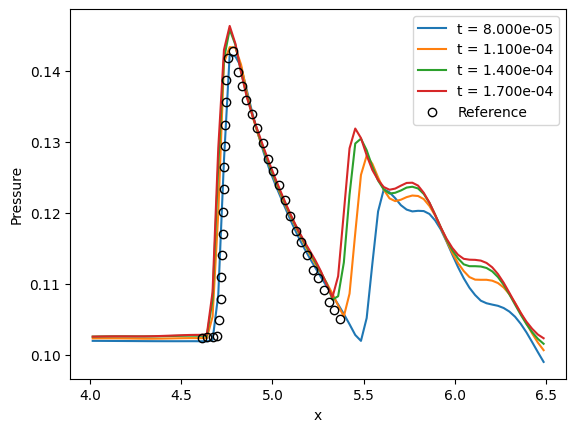

In [101]:


files = os.listdir(".")
plts = [f for f in files if re.fullmatch(r"plt\d+", f)]
plts.sort(key=lambda f: int(f[3:]))
plts = [f for f in plts if int(f[3:]) >= 6718][::3]

# reference (plot once)
p_ref = pd.read_csv("presRefL2.csv")

plt.figure()
for f in plts:
    ds  = yt.load(f)
    ray = ds.ortho_ray(0, (1.0, 0.25))   # x-parallel ray at y=1.0, z=0.25

    x = np.array(ray["x"])
    p = np.array(ray["pressure"] / 1e7)
    srt = np.argsort(x)
    x, p = x[srt], p[srt]

    m = (x >= 4.0) & (x <= 6.5)
    plt.plot(x[m], p[m], label=f"t = {float(ds.current_time):.3e}")

# reference, hollow black markers
plt.plot(p_ref["x"]/10, p_ref["Pressure"],
         linestyle="", marker="o", markevery=2,
         markerfacecolor="none", markeredgecolor="black",
         label="Reference")

plt.xlabel("x")
plt.ylabel("Pressure")
plt.legend()
plt.show()

yt : [INFO     ] 2026-08-04 07:05:42,191 Parameters: current_time              = 8.000019628851029e-05
yt : [INFO     ] 2026-08-04 07:05:42,192 Parameters: domain_dimensions         = [400  48  16]
yt : [INFO     ] 2026-08-04 07:05:42,192 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2026-08-04 07:05:42,193 Parameters: domain_right_edge         = [12.5  1.5  0.5]
yt : [INFO     ] 2026-08-04 07:05:42,611 Parameters: current_time              = 0.00011000186336491491
yt : [INFO     ] 2026-08-04 07:05:42,612 Parameters: domain_dimensions         = [400  48  16]
yt : [INFO     ] 2026-08-04 07:05:42,613 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2026-08-04 07:05:42,613 Parameters: domain_right_edge         = [12.5  1.5  0.5]
yt : [INFO     ] 2026-08-04 07:05:42,964 Parameters: current_time              = 0.00014000568697791006
yt : [INFO     ] 2026-08-04 07:05:42,965 Parameters: domain_dimensions         = [400  48  16]
yt : [INFO     ] 2026-08

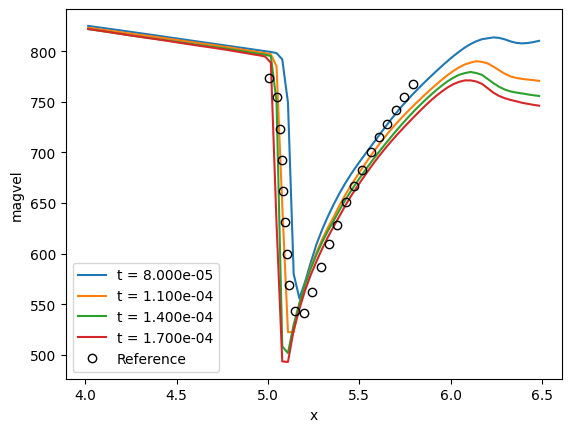

In [102]:
files = os.listdir(".")
plts = [f for f in files if re.fullmatch(r"plt\d+", f)]
plts.sort(key=lambda f: int(f[3:]))
plts = [f for f in plts if int(f[3:]) >= 6718][::3]

# reference (plot once)
v_ref = pd.read_csv("BLVelRef.csv")

plt.figure()
for f in plts:
    ds  = yt.load(f)
    ray = ds.ortho_ray(0, (1.49999, 0.25))   # x-parallel ray at y=1.49999, z=0.25

    x = np.array(ray["x"])
    p = np.array(ray["magvel"] / 100)
    srt = np.argsort(x)
    x, p = x[srt], p[srt]

    m = (x >= 4.0) & (x <= 6.5)
    plt.plot(x[m], p[m], label=f"t = {float(ds.current_time):.3e}")

# reference, hollow black markers
plt.plot(v_ref["x"]/10, v_ref["velocity"],
         linestyle="", marker="o", markevery=3,
         markerfacecolor="none", markeredgecolor="black",
         label="Reference")

plt.xlabel("x")
plt.ylabel("magvel")
plt.legend()
plt.show()

---
# SGS closure comparison — non-reacting CLEM (Maxwell)

Every case below is CLEM with the Maxwell chain and `clem.do_react = 0`; the
**only** thing that varies is the SGS closure. Reference is the digitised L2
data from Jin et al., *Combust. Flame* **268** (2024) 113627 — always **hollow
black circles, no line**; each closure is a **solid line with its own marker**.

Run the cells in order. `print_inventory()` in the config cell says which cases
have reached `TCMP`; any that have not are skipped with a warning rather than
silently plotted at the wrong instant.

| figure | what it answers |
|---|---|
| 1 | pressure at y = 1.0 cm and top-wall velocity, all closures at one instant |
| 2 | is that instant late enough, or still transient? |
| 3 | numerical schlieren on z = 0.25 cm — the shock/wave system |
| 4 | Q-criterion isosurface coloured by Y(H₂) — the vortex system that mixes |


  skipped (no data at 0.180 ms): (ii) Smagorinsky, Cs=0.16


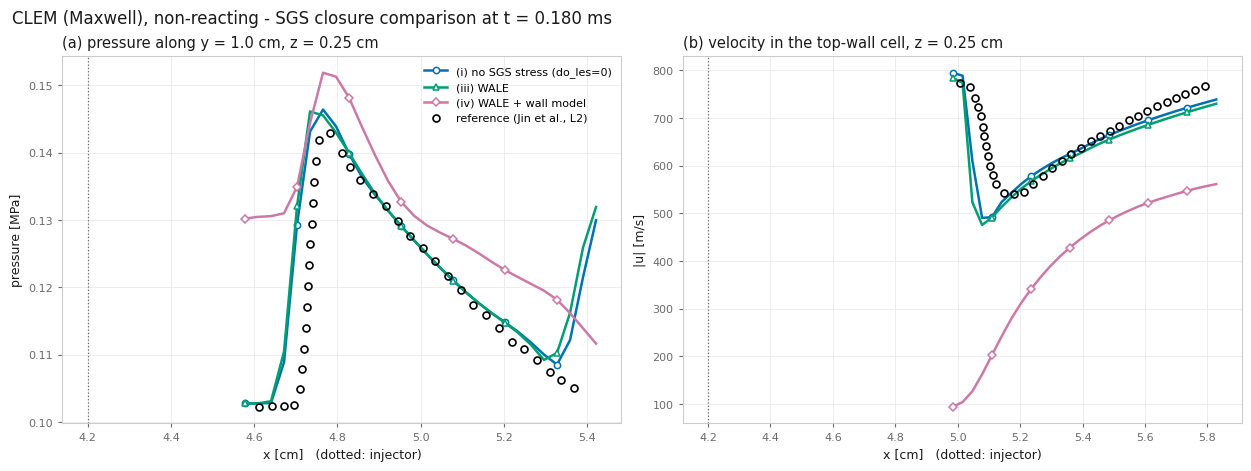

In [5]:
# ===== FIGURE 1 - both probes, every closure, one instant ====================
fig, (a, b) = plt.subplots(1, 2, figsize=(12.4, 4.6), constrained_layout=True)

for ax, tag, (yprobe, fld, sc, ref, refcol, ylab, title) in zip((a, b), "ab", PROBES):
    xr = ref["x"].to_numpy() / 10.0                     # mm -> cm
    for lab, pat, col, mk in CASES:
        t, p = at_time(pat, TCMP)
        if p is None:
            if tag == "a":
                print(f"  skipped (no data at {TCMP*1e3:.3f} ms): {lab}")
            continue
        x, f = ray_x(yt.load(p), yprobe, 0.25, fld, sc)
        m = (x >= xr.min() - 0.05) & (x <= xr.max() + 0.05)
        ax.plot(x[m], f[m], "-", color=col, lw=1.8, marker=mk, ms=4.5,
                markevery=4, mfc="white", mew=1.1, label=lab)
    ax.plot(xr, ref[refcol], linestyle="", marker="o", ms=5, markevery=2,
            mfc="none", mec="black", mew=1.2, label="reference (Jin et al., L2)")
    ax.axvline(XJET, color=MUTED, lw=0.9, ls=":")
    style(ax, "x [cm]   (dotted: injector)", ylab, f"({tag}) {title}")

a.legend(fontsize=8, frameon=False, loc="best")
fig.suptitle("CLEM (Maxwell), non-reacting - SGS closure comparison at "
             f"t = {TCMP*1e3:.3f} ms", fontsize=12, color=INK, x=0.005, ha="left")
fig.savefig(f"{OUT}/compare_lines_t{TCMP*1e3:.2f}ms.png", dpi=160, facecolor="white")
plt.show()

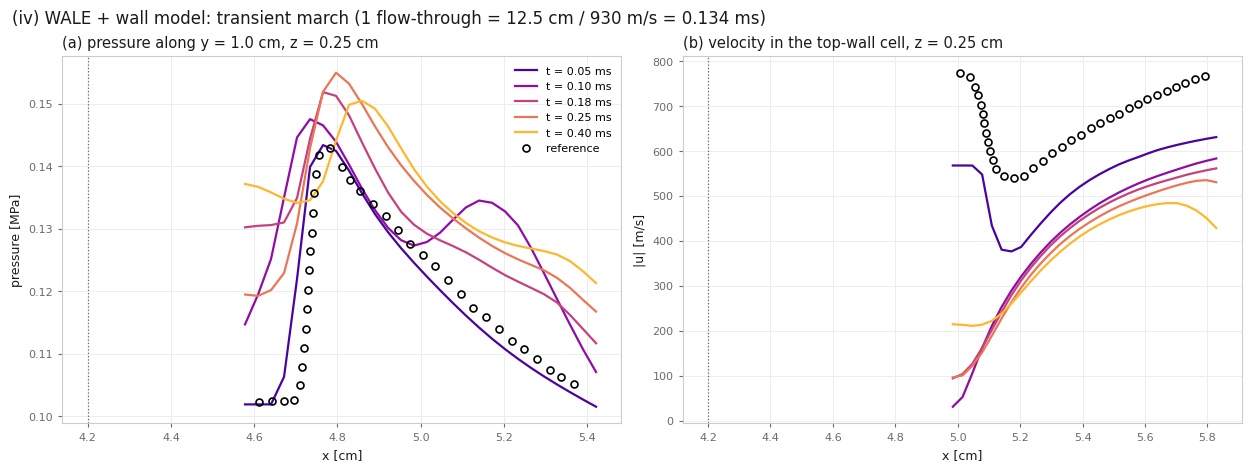

In [6]:
# ===== FIGURE 2 - transient check ============================================
# Figure 1 is a snapshot. If a case is still marching, disagreement with the
# reference means "not converged", not "wrong closure" - this separates the two.
# Set MARCH_CASE to whichever case you want to follow in time.
MARCH_CASE = "(iv) WALE + wall model"
MARCH_TIMES = [5e-5, 1.0e-4, 1.8e-4, 2.5e-4, 4.0e-4]

pat = dict((c[0], c[1]) for c in CASES)[MARCH_CASE]
fig, (a, b) = plt.subplots(1, 2, figsize=(12.4, 4.6), constrained_layout=True)
cmap = plt.get_cmap("plasma")

for ax, tag, (yprobe, fld, sc, ref, refcol, ylab, title) in zip((a, b), "ab", PROBES):
    xr = ref["x"].to_numpy() / 10.0
    for k, tt in enumerate(MARCH_TIMES):
        t, p = at_time(pat, tt)
        if p is None:
            continue
        x, f = ray_x(yt.load(p), yprobe, 0.25, fld, sc)
        m = (x >= xr.min() - 0.05) & (x <= xr.max() + 0.05)
        ax.plot(x[m], f[m], "-", lw=1.6, label=f"t = {t*1e3:.2f} ms", color=cmap(0.12 + 0.72 * k / max(len(MARCH_TIMES) - 1, 1)))
    ax.plot(xr, ref[refcol], linestyle="", marker="o", ms=5, markevery=2,
            mfc="none", mec="black", mew=1.2, label="reference")
    ax.axvline(XJET, color=MUTED, lw=0.9, ls=":")
    style(ax, "x [cm]", ylab, f"({tag}) {title}")

a.legend(fontsize=8, frameon=False, loc="best")
fig.suptitle(f"{MARCH_CASE}: transient march "
             "(1 flow-through = 12.5 cm / 930 m/s = 0.134 ms)",
             fontsize=12, color=INK, x=0.005, ha="left")
fig.savefig(f"{OUT}/compare_lines_transient.png", dpi=160, facecolor="white")
plt.show()

  skipped: (ii) Smagorinsky, Cs=0.16
shared scale |grad rho|_99.5 = 0.002794 g/cm^4


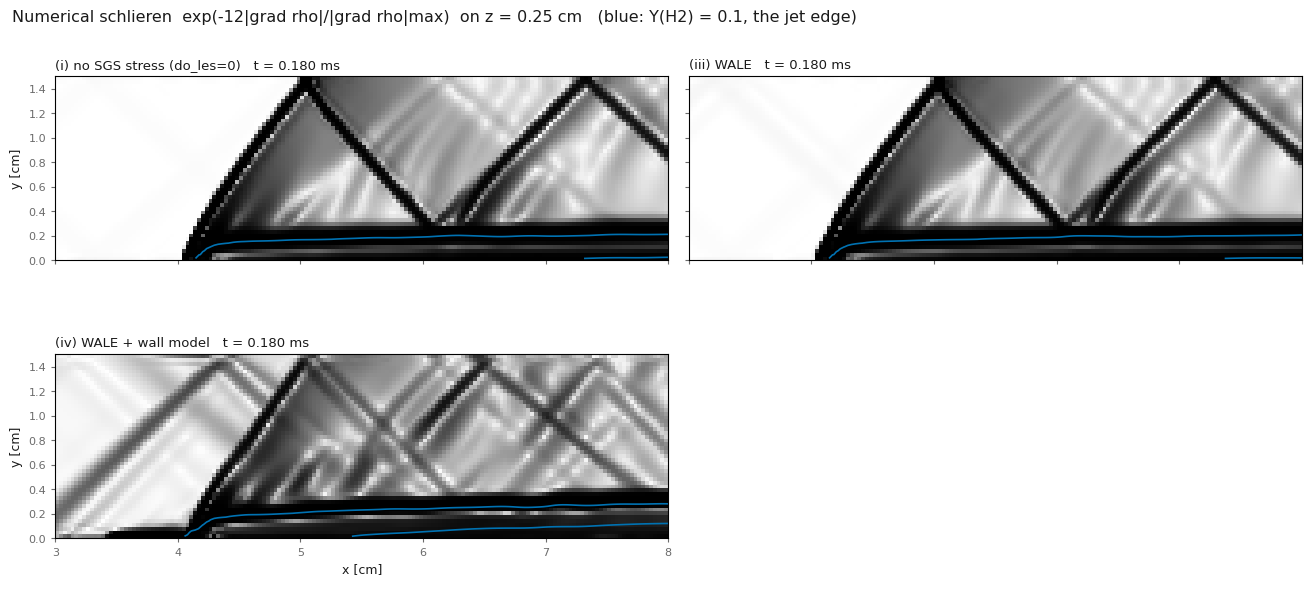

In [7]:
# ===== FIGURE 3 - numerical schlieren on z = 0.25 cm =========================
# |grad rho| through the jet centreplane: bow shock, barrel shock, reflections.
# This is what the y = 1.0 cm pressure trace in figure 1 is cutting through.
XW = (3.0, 8.0)          # x window [cm]
KSCHL = 12.0             # contrast; larger = darker/sharper

panels = {}
for lab, pat, col, mk in CASES:
    t, p = at_time(pat, TCMP)
    if p is None:
        print(f"  skipped: {lab}")
        continue
    ds = yt.load(p)
    g, dx = cgrid(ds)
    rho = g("density")
    gr = np.sqrt(sum(np.gradient(rho, dx[b], axis=b, edge_order=2) ** 2 for b in range(3)))
    kz = int(0.25 / dx[2])
    panels[lab] = (t, gr[:, :, kz], g("Y(H2)")[:, :, kz], dx)

# ONE normalisation across all panels, else they cannot be compared by eye
gmax = max(np.percentile(v[1], 99.5) for v in panels.values())
print(f"shared scale |grad rho|_99.5 = {gmax:.4g} g/cm^4")

n = len(panels)
fig, axs = plt.subplots((n + 1) // 2, 2, figsize=(13.0, 2.9 * ((n + 1) // 2)),
                        constrained_layout=True, sharex=True, sharey=True, squeeze=False)
for ax, (lab, (t, gr, yh2, dx)) in zip(axs.ravel(), panels.items()):
    xe = np.arange(gr.shape[0] + 1) * dx[0]
    ye = np.arange(gr.shape[1] + 1) * dx[1]
    ax.pcolormesh(xe, ye, np.exp(-KSCHL * gr / gmax).T, cmap="gray",
                  vmin=0.0, vmax=1.0, shading="flat", rasterized=True)
    ax.contour(xe[:-1] + 0.5 * dx[0], ye[:-1] + 0.5 * dx[1], yh2.T,
               levels=[0.1], colors="#0072B2", linewidths=1.2)
    ax.set_xlim(*XW)
    ax.set_aspect("equal")
    ax.set_title(f"{lab}   t = {t*1e3:.3f} ms", loc="left", fontsize=9.5, color=INK)
    ax.tick_params(colors=MUTED, labelsize=8, length=3)
for ax in axs[-1]:
    ax.set_xlabel("x [cm]", fontsize=9, color=INK)
for ax in axs[:, 0]:
    ax.set_ylabel("y [cm]", fontsize=9, color=INK)
for ax in axs.ravel()[n:]:
    ax.axis("off")

fig.suptitle(f"Numerical schlieren  exp(-{KSCHL:.0f}|grad rho|/|grad rho|max)  "
             "on z = 0.25 cm   (blue: Y(H2) = 0.1, the jet edge)",
             fontsize=11.5, color=INK, x=0.005, ha="left")
fig.savefig(f"{OUT}/compare_schlieren_t{TCMP*1e3:.2f}ms.png", dpi=170, facecolor="white")
plt.show()

  (i) no SGS stress (do_les=0)        772 triangles
  skipped: (ii) Smagorinsky, Cs=0.16
  (iii) WALE                          762 triangles
  (iv) WALE + wall model             3094 triangles


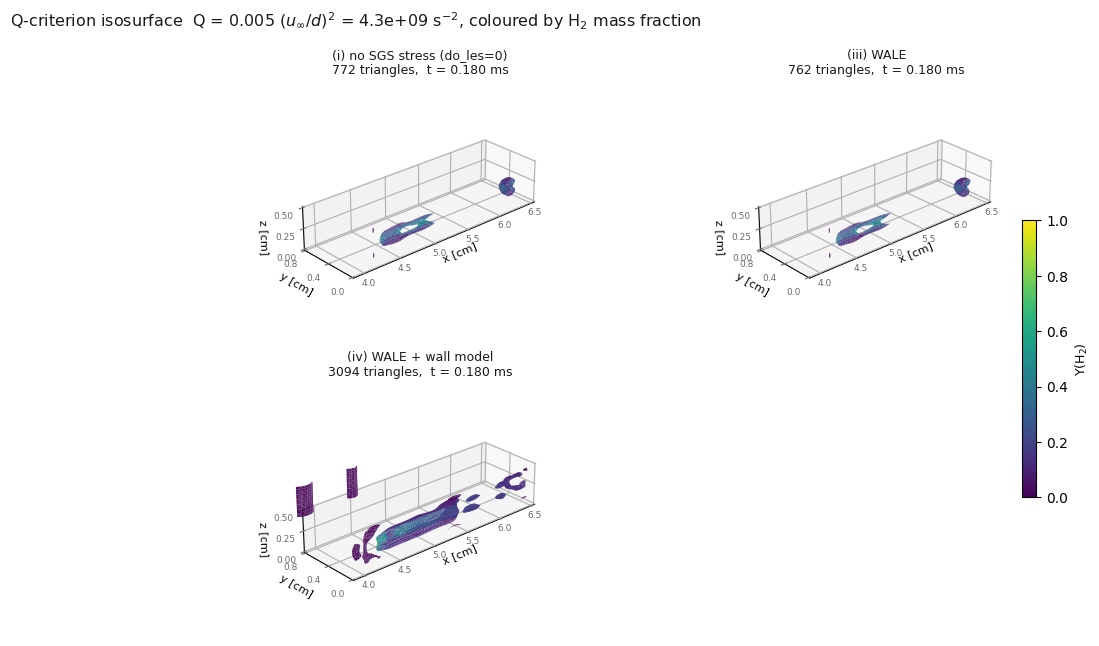

In [8]:
# ===== FIGURE 4 - Q-criterion isosurface coloured by Y(H2) ===================
# CAVEAT: only 16 cells span z (dz = 0.3125 mm) and the jet is 1 mm across, so
# the counter-rotating vortex pair is ~3 cells wide. These surfaces show WHERE
# vortices are and whether they carry H2, not their fine structure.
QREF  = (UINF / DJET) ** 2          # (u_inf/d)^2, the natural Q scale
QFRAC = 0.005                       # same ABSOLUTE level in every panel
XS    = (3.9, 6.5)                  # x window [cm]; keeps the triangle count sane
YS    = (0.0, 0.8)

surfaces = {}
for lab, pat, col, mk in CASES:
    t, p = at_time(pat, TCMP)
    if p is None:
        print(f"  skipped: {lab}")
        continue
    ds = yt.load(p)
    g, dx = cgrid(ds)
    Q = qcrit(g("x_velocity"), g("y_velocity"), g("z_velocity"), dx)
    bbox = np.array([[float(ds.domain_left_edge[i]), float(ds.domain_right_edge[i])]
                     for i in range(3)])
    ds2 = yt.load_uniform_grid({"Q": Q, "YH2": g("Y(H2)")}, Q.shape,
                               length_unit="cm", bbox=bbox, nprocs=1)
    # Inset by 2 cells: yt asks for one ghost layer and the y walls are NOT
    # periodic, so a source touching the boundary raises a read-outside error.
    le = np.array([XS[0], bbox[1, 0] + 2 * dx[1], bbox[2, 0] + 2 * dx[2]])
    re = np.array([XS[1], bbox[1, 1] - 2 * dx[1], bbox[2, 1] - 2 * dx[2]])
    surf = ds2.surface(ds2.region(0.5 * (le + re), le, re), "Q", QFRAC * QREF)
    surfaces[lab] = (t, np.array(surf.triangles), np.array(surf["YH2"]))
    print(f"  {lab:<32} {len(surfaces[lab][1]):6d} triangles")

n = len(surfaces)
fig = plt.figure(figsize=(13.0, 3.6 * ((n + 1) // 2)))
for k, (lab, (t, tri, cval)) in enumerate(surfaces.items(), 1):
    ax = fig.add_subplot((n + 1) // 2, 2, k, projection="3d")
    if len(tri):
        pc = Poly3DCollection(tri, linewidths=0.0)
        pc.set_array(np.clip(cval, 0.0, 1.0))
        pc.set_cmap("viridis")       # perceptually uniform and CVD-safe
        pc.set_clim(0.0, 1.0)
        ax.add_collection3d(pc)
    ax.set_xlim(*XS); ax.set_ylim(*YS); ax.set_zlim(0, 0.5)
    ax.set_box_aspect((XS[1] - XS[0], YS[1] - YS[0], 0.5))
    ax.view_init(elev=26, azim=-132)
    # matplotlib's default 3D locator crams ~8 labels onto a 0.5 cm axis and
    # they overlap into mush - set them explicitly.
    ax.set_xticks(np.arange(np.ceil(XS[0] * 2) / 2, XS[1] + 0.01, 0.5))
    ax.set_yticks([YS[0], 0.5 * (YS[0] + YS[1]), YS[1]])
    ax.set_zticks([0.0, 0.25, 0.5])
    ax.set_title(f"{lab}\n{len(tri)} triangles,  t = {t*1e3:.3f} ms",
                 fontsize=9, color=INK)
    ax.set_xlabel("x [cm]", fontsize=8, labelpad=-2)
    ax.set_ylabel("y [cm]", fontsize=8, labelpad=-6)
    ax.set_zlabel("z [cm]", fontsize=8, labelpad=-6)
    ax.tick_params(labelsize=6.5, colors=MUTED, pad=-1)

sm = plt.cm.ScalarMappable(cmap="viridis", norm=plt.Normalize(0, 1))
fig.colorbar(sm, ax=fig.axes, shrink=0.5, pad=0.02).set_label("Y(H$_2$)", fontsize=9)
fig.suptitle(f"Q-criterion isosurface  Q = {QFRAC} $(u_\\infty/d)^2$ "
             f"= {QFRAC*QREF:.2g} s$^{{-2}}$, coloured by H$_2$ mass fraction",
             fontsize=11.5, color=INK, x=0.005, ha="left")
fig.savefig(f"{OUT}/compare_qcriterion_t{TCMP*1e3:.2f}ms.png", dpi=170,
            facecolor="white", bbox_inches="tight")
plt.show()

In [12]:
ds = yt.load("../ResultsNonReact/CLEM-WALE-WM/plt_nrWM35640")

In [13]:
g, dx = cgrid(ds)
Q = qcrit(g("x_velocity"), g("y_velocity"), g("z_velocity"), dx)
bbox = np.array([[float(ds.domain_left_edge[i]), float(ds.domain_right_edge[i])] for i in range(3)])

ds2 = yt.load_uniform_grid({"Q": Q, "YH2": g("Y(H2)")}, Q.shape, length_unit="cm", bbox=bbox, nprocs=1)
# Inset by 2 cells: yt asks for one ghost layer and the y walls are NOT
# periodic, so a source touching the boundary raises a read-outside error.
le = np.array([XS[0], bbox[1, 0] + 2 * dx[1], bbox[2, 0] + 2 * dx[2]])
re = np.array([XS[1], bbox[1, 1] - 2 * dx[1], bbox[2, 1] - 2 * dx[2]])

surf_ = ds2.surface(ds2.region(0.5 * (le + re), le, re), "Q", QFRAC * QREF)
surface_ = (t, np.array(surf.triangles), np.array(surf["YH2"]))


  (iv) WALE + wall model             3094 triangles


t = 0.400 ms   4889 triangles   Y(H2) 0.000-0.856


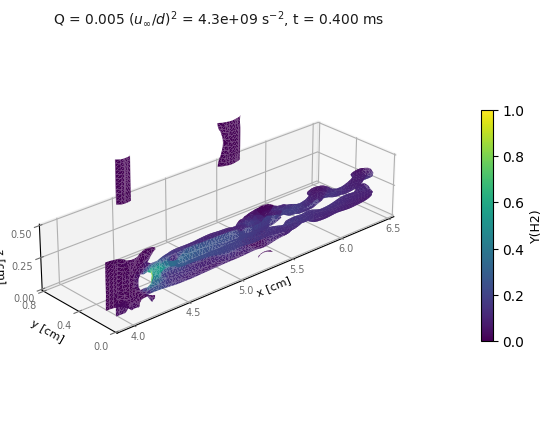

In [15]:
# ---- one Q isosurface, one plotfile -----------------------------------------
PLT   = "/home/pc08/Fernando/CLEMNew/PeleC-CLEM/Exec/RegTests/CrossJet/ResultsNonReact/CLEM-WALE-WM/plt_nrWM35640"
QFRAC = 0.005                       # level as a fraction of (u_inf/d)^2
XS    = (3.9, 6.5)                  # x window [cm]
YS    = (0.0, 0.8)                  # y window [cm]
CFIELD = "Y(H2)"                    # field the surface is coloured by

QREF = (UINF / DJET) ** 2

ds = yt.load(PLT)
g, dx = cgrid(ds)
Q = qcrit(g("x_velocity"), g("y_velocity"), g("z_velocity"), dx)

bbox = np.array([[float(ds.domain_left_edge[i]), float(ds.domain_right_edge[i])] for i in range(3)])
ds2 = yt.load_uniform_grid({"Q": Q, "C": g(CFIELD)}, Q.shape,  length_unit="cm", bbox=bbox, nprocs=1)

# Inset by 2 cells: yt pulls one ghost layer and the y walls are NOT periodic,
# so a data source touching the boundary raises a read-outside-domain error.
# NOTE: do not name these le/re - `re` shadows the regex module from cell 0.
lo_edge = np.array([XS[0], bbox[1, 0] + 2 * dx[1], bbox[2, 0] + 2 * dx[2]])
hi_edge = np.array([XS[1], bbox[1, 1] - 2 * dx[1], bbox[2, 1] - 2 * dx[2]])
reg = ds2.region(0.5 * (lo_edge + hi_edge), lo_edge, hi_edge)

surf = ds2.surface(reg, "Q", QFRAC * QREF)
tri  = np.array(surf.triangles)
cval = np.array(surf["C"])


fig = plt.figure(figsize=(9.0, 5.0))
ax = fig.add_subplot(111, projection="3d")
if len(tri):
    pc = Poly3DCollection(tri, linewidths=0.0)
    pc.set_array(np.clip(cval, 0.0, 1.0))
    pc.set_cmap("viridis")
    pc.set_clim(0.0, 1.0)
    ax.add_collection3d(pc)
    fig.colorbar(pc, ax=ax, shrink=0.6, pad=0.10).set_label(CFIELD, fontsize=9)
else:
    print("empty surface - lower QFRAC")

ax.set_xlim(*XS); ax.set_ylim(*YS); ax.set_zlim(0, 0.5)
ax.set_box_aspect((XS[1] - XS[0], YS[1] - YS[0], 0.5))
ax.view_init(elev=26, azim=-132)
ax.set_xticks(np.arange(np.ceil(XS[0] * 2) / 2, XS[1] + 0.01, 0.5))
ax.set_yticks([YS[0], 0.5 * (YS[0] + YS[1]), YS[1]])
ax.set_zticks([0.0, 0.25, 0.5])
ax.set_xlabel("x [cm]", fontsize=8, labelpad=-2)
ax.set_ylabel("y [cm]", fontsize=8, labelpad=-6)
ax.set_zlabel("z [cm]", fontsize=8, labelpad=-6)
ax.tick_params(labelsize=7, colors=MUTED, pad=-1)
ax.set_title(f"Q = {QFRAC} $(u_\\infty/d)^2$ = {QFRAC*QREF:.2g} s$^{{-2}}$, "
             f"t = {float(ds.current_time)*1e3:.3f} ms", fontsize=10, color=INK)
plt.show()

In [66]:
# ---- the two closures compared in the cells below ---------------------------
# Both plotfiles sit at EXACTLY t = 0.400 ms, so this is a matched-time
# comparison and the only thing that differs is pelec.les_model.
# NOTE: the Smagorinsky file lives in CLEM-Smagorinsky, NOT in CLEM-WALE-WM.
ds_WALE = yt.load(OUT + "/CLEM-WALE-WM/plt_nrWM35640")
ds_SMGY = yt.load(OUT + "/CLEM-Smagorinsky/plt_nrS33722")

# label, dataset, colour. Colours are the CASES ones - a case must never change
# colour between figures.
PAIR = [("(i) WALE-WM",    ds_WALE, "#CC79A7"),
        ("(ii) Smagorinsky, Cs=0.16", ds_SMGY, "#D55E00")]

XW   = (2.75, 9.75)      # x window [cm] = centre 6.25, width 7
ZMID = 0.25              # jet centreplane

for lab, d, _c in PAIR:
    print(f"{lab:<28} t = {float(d.current_time)*1e3:.4f} ms")

(i) WALE-WM                  t = 0.4000 ms
(ii) Smagorinsky, Cs=0.16    t = 0.4000 ms


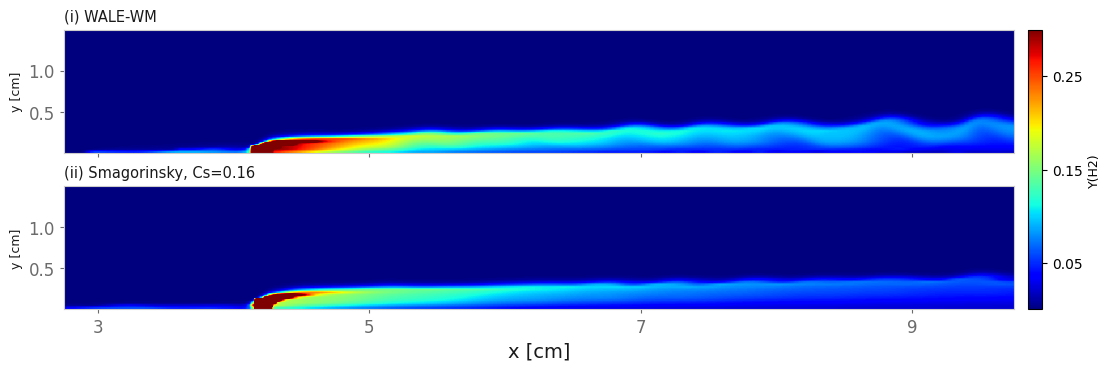

In [73]:
# ===== z = 0.25 cm slice of Y(H2), both closures, ONE shared colour bar ======
# Built from the covering grid rather than two yt SlicePlots: two yt figures
# cannot share a colour bar, and without a shared bar the panels cannot be
# compared by eye.
fig, axes = plt.subplots(2, 1, figsize=(11.0, 3.6), sharex=True, sharey=True,
                         constrained_layout=True)
im = None
for ax, (lab, ds_, _c) in zip(axes, PAIR):
    g, dx = cgrid(ds_)
    # Average the two cells straddling z = 0.25: only 16 cells span z, so no
    # cell centre lands exactly on the centreplane.
    zc = (np.arange(ds_.domain_dimensions[2]) + 0.5) * dx[2]
    k = np.argsort(np.abs(zc - ZMID))[:2]
    f = g("Y(H2)")[:, :, k].mean(axis=2)
    i0, i1 = int(XW[0] / dx[0]), int(XW[1] / dx[0])
    im = ax.imshow(f[i0:i1].T, origin="lower", cmap="jet", vmin=0.0, vmax=0.3,
                   extent=[XW[0], XW[1], 0.0, 1.5], aspect="auto")
    style(ax, "", "y [cm]", lab)
    ax.grid(False)                       # style() turns it on; wrong over an image
    ax.set_yticks([0.5, 1.0])
for ax in axes:
    ax.tick_params(axis='both', labelsize=12)  # Adjust size as needed
axes[-1].set_xlabel("x [cm]", fontsize=14, color=INK)
axes[-1].set_xticks([3, 5, 7, 9])
cb = fig.colorbar(im, ax=axes, ticks=[0.05, 0.15, 0.25], pad=0.015)
cb.set_label("Y(H2)", fontsize=9)

fig.savefig(f"{OUT}/compare_slice_YH2_z025.pdf", bbox_inches="tight")
plt.show()

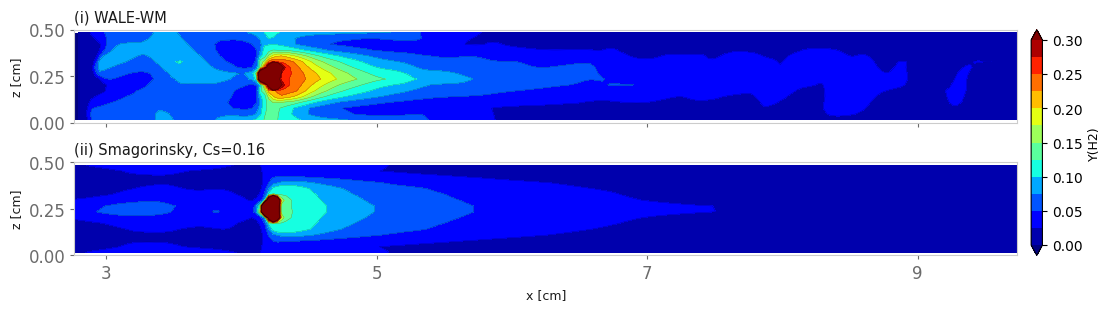

In [76]:
# ===== y = 0.02 cm (first cell off the bottom wall): CONTOURS, shared bar ====
# Discrete filled contours rather than a continuous field, so the two closures
# can be compared level by level instead of by shade.
# Laid out with x horizontal and z vertical: yt's y-normal slice is (z, x),
# which would make this 7 cm x 0.5 cm strip a 14:1 tower.
def wall_contours(field, scale, label, levels, fname, cmap="jet", jy=0):
    """Both closures, same levels, one colour bar. jy = 0 is the first cell off
    the wall - y = 0.02 cm falls inside it (dy = 0.03125 cm)."""
    fig, axes = plt.subplots(2, 1, figsize=(11.0, 3.0), sharex=True,
                             sharey=True, constrained_layout=True)
    cf = None
    for ax, (lab, ds_, _c) in zip(axes, PAIR):
        g, dx = cgrid(ds_)
        f = g(field)[:, jy, :] * scale
        i0, i1 = int(XW[0] / dx[0]), int(XW[1] / dx[0])
        xc = (np.arange(i0, i1) + 0.5) * dx[0]
        zc = (np.arange(ds_.domain_dimensions[2]) + 0.5) * dx[2]
        cf = ax.contourf(xc, zc, f[i0:i1].T, levels=levels, cmap=cmap,
                         extend="both")
        ax.contour(xc, zc, f[i0:i1].T, levels=levels, colors="k",
                   linewidths=0.25, alpha=0.45)
        style(ax, "", "z [cm]", lab)
        ax.grid(False)
        ax.set_yticks([0.0, 0.25, 0.5])
    axes[-1].set_xlabel("x [cm]", fontsize=9, color=INK)
    axes[-1].set_xticks([3, 5, 7, 9])
    cb = fig.colorbar(cf, ax=axes, pad=0.015)
    cb.set_label(label, fontsize=9)
    fig.savefig(fname, bbox_inches="tight")

    for ax in axes:
        ax.tick_params(axis='both', labelsize=12)  # Adjust size as needed
    return fig


wall_contours("Y(H2)", 1.0, "Y(H2)", np.linspace(0.0, 0.3, 13),
              f"{OUT}/compare_wall_YH2_contour.pdf")
plt.show()

shared |u| ceiling = 1500.4 m/s


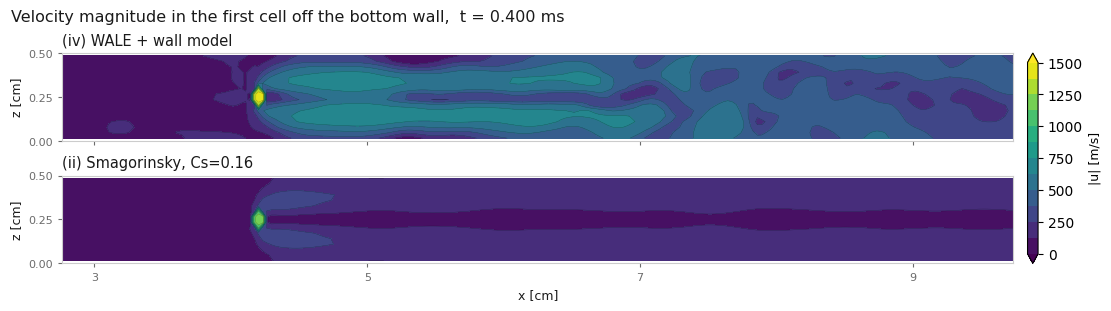

In [62]:
# ===== same plane, |u| - contours, one shared bar across both closures =======
# The ceiling is taken over BOTH datasets so the level set is identical; taking
# it per panel would rescale each one and hide the difference.
gm = max(cgrid(d)[0]("magvel").max() for _lab, d, _c in PAIR) / 100.0
print(f"shared |u| ceiling = {gm:.1f} m/s")

wall_contours("magvel", 0.01, "|u| [m/s]", np.linspace(0.0, gm, 13),
              f"{OUT}/compare_wall_magvel_contour.pdf", cmap="viridis")
plt.suptitle("Velocity magnitude in the first cell off the bottom wall,  "
             "t = 0.400 ms", fontsize=11.5, color=INK, x=0.005, ha="left")
plt.show()

shared |grad rho|max = 0.009592 g/cm^4


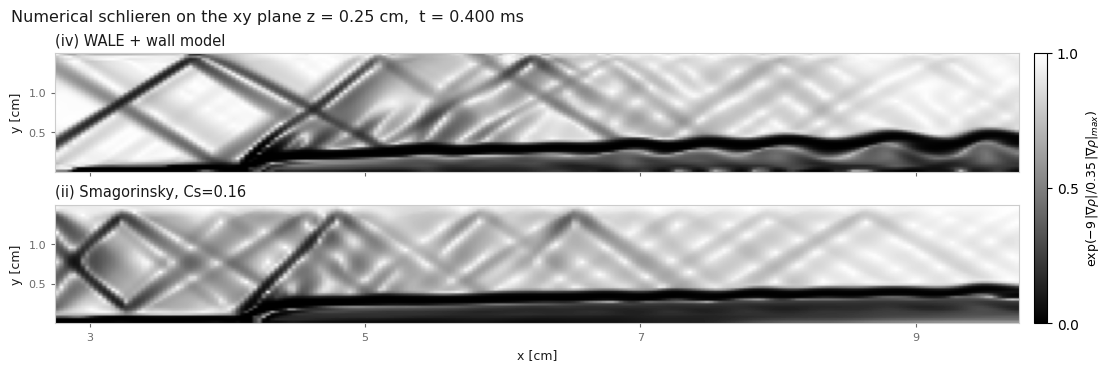

In [63]:
# ===== numerical schlieren, xy plane at z = 0.25 cm, ONE shared scale ========
# |grad rho| is formed on the FULL 3-D grid and only then sliced. Slicing first
# would leave a 2-D array whose gradient has no out-of-plane component, which
# quietly weakens every oblique wave.
fig, axes = plt.subplots(2, 1, figsize=(11.0, 3.6), sharex=True, sharey=True,
                         constrained_layout=True)
sch = []
for lab, ds_, _c in PAIR:
    g, dx = cgrid(ds_)
    rho = g("density")
    gr = np.sqrt(sum(np.gradient(rho, dx[b], axis=b, edge_order=2) ** 2
                     for b in range(3)))
    zc = (np.arange(ds_.domain_dimensions[2]) + 0.5) * dx[2]
    k = np.argsort(np.abs(zc - ZMID))[:2]
    sch.append((lab, gr[:, :, k].mean(axis=2), dx))

gmax = max(s[1].max() for s in sch)     # one normalisation, else no comparison
print(f"shared |grad rho|max = {gmax:.4g} g/cm^4")

im = None
for ax, (lab, gr, dx) in zip(axes, sch):
    s = np.exp(-9.0 * gr / (0.35 * gmax))
    i0, i1 = int(XW[0] / dx[0]), int(XW[1] / dx[0])
    im = ax.imshow(s[i0:i1].T, origin="lower", cmap="gray", vmin=0.0, vmax=1.0,
                   extent=[XW[0], XW[1], 0.0, 1.5], aspect="auto")
    style(ax, "", "y [cm]", lab)
    ax.grid(False)
    ax.set_yticks([0.5, 1.0])

axes[-1].set_xlabel("x [cm]", fontsize=9, color=INK)
axes[-1].set_xticks([3, 5, 7, 9])
cb = fig.colorbar(im, ax=axes, ticks=[0.0, 0.5, 1.0], pad=0.015)
cb.set_label(r"exp$(-9\,|\nabla\rho| / 0.35\,|\nabla\rho|_{max})$", fontsize=9)
fig.suptitle("Numerical schlieren on the xy plane z = 0.25 cm,  t = 0.400 ms",
             fontsize=11.5, color=INK, x=0.005, ha="left")
fig.savefig(f"{OUT}/compare_schlieren_xy_z025.pdf", bbox_inches="tight")
plt.show()

---
## Stirring activity per timestep

The plotfiles say nothing about how hard CLEM's stirring stage actually worked
— that only exists in the run log, which prints one line per step from
`ClemAlgorithm.cpp`:

```
CLEM stirring: maps applied = 112 over 307200 lines (max = 1/line),
eddies rejected as too small = 76648 (99.85% of those drawn),
lines truncated by the substep cap = 0
```

Two different quantities are compared below, and they are *not*
interchangeable:

| quantity | meaning |
|---|---|
| **processes drawn** | eddy events sampled from $f(\ell)\sim\ell^{-8/3}$ — what the closure **asks for**, set by $D_T=\nu_t$ |
| **maps applied** | events that actually fit on the LEM line and were mapped — what the line **receives** |

They differ by the `n_lem = 12` rejection. Both runs have the *identical* CLEM
block, so any gap between them is the LES closure acting through $\nu_t$.


case                          steps   drawn/step  applied/step  applied %
(ii) Smagorinsky, Cs=0.16     33722      71338.7        298.91      0.419
(iv) WALE + wall model        35640        715.0          1.90      0.266


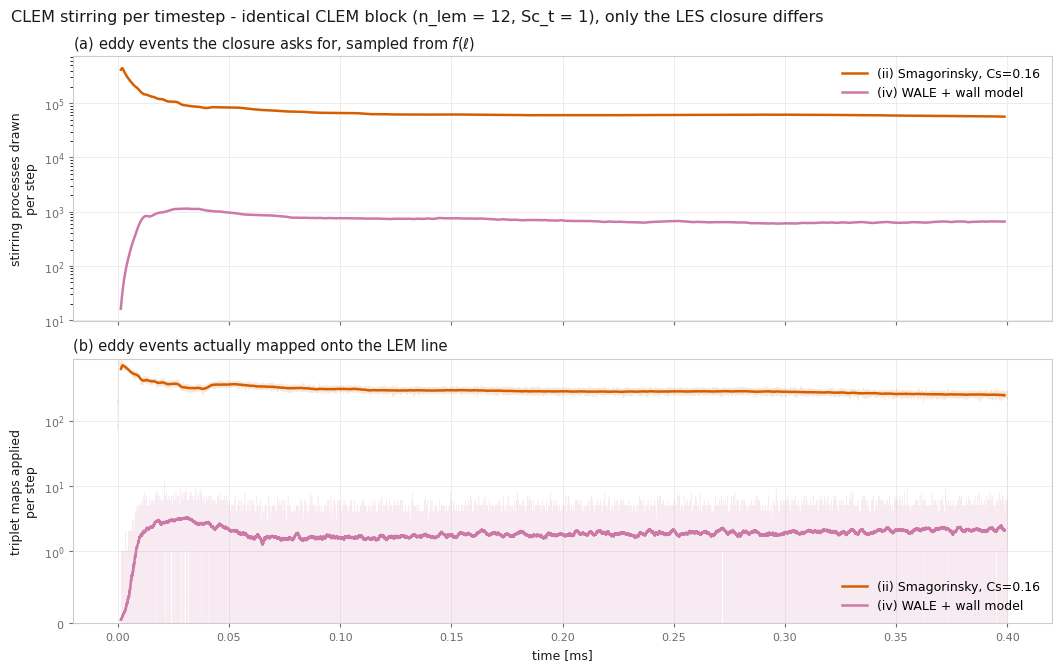

In [64]:
# ===== stirring: processes DRAWN vs triplet maps APPLIED =====================
# stirring_from_log.py ties each "CLEM stirring:" line to the
# "[Level 0 step N] ADVANCE at time T with dt = DT" line opening the same block,
# which is where the step number and physical time come from.
# Safe to run while Smagorinsky is still marching: the trailing partial block
# is dropped, so the curve simply ends wherever the log currently ends.
import sys

if AN not in sys.path:
    sys.path.insert(0, AN)
import stirring_from_log as sfl

STIR = [("(i) Smagorinsky, Cs=0.16", ROOT + "/NonReactSmagorisnky.log",        "#D55E00"),
        ("(i) WALE-WM",    OUT + "/CLEM-WALE-WM/nonReactWaleWM.log", "#CC79A7")]
COL = {n: i for i, n in enumerate(sfl.COLS)}


def roll(y, n=201):
    """Centred rolling mean with the ends blanked. mode='same' zero-pads, which
    drags the last n/2 points down and draws a cliff that reads as the stirring
    shutting off at the end of the run."""
    if len(y) < n:
        return y
    o = np.convolve(y, np.ones(n) / n, mode="same")
    o[:n // 2] = np.nan
    o[-(n // 2):] = np.nan
    return o


fig, ax = plt.subplots(2, 1, figsize=(10.5, 6.6), sharex=True,
                       constrained_layout=True)
print(f"{'case':<28}{'steps':>7}{'drawn/step':>13}{'applied/step':>14}"
      f"{'applied %':>11}")

for lab, log, col in STIR:
    a = np.array(sfl.parse(log), dtype=float)
    t = a[:, COL["time"]] * 1e3
    drawn, applied = a[:, COL["drawn"]], a[:, COL["maps"]]
    ax[0].plot(t, roll(drawn), color=col, lw=1.8, label=lab)



ax[0].set_yscale("log")
style(ax[0], "", "stirring processes drawn\nper step",
      r"(a) eddy events the closure asks for, sampled from $f(\ell)$")
# symlog to keep the WALE zeros visible; without the ylim it auto-scales
# symmetrically and puts -10^9 on a count that can never be negative.
ax[1].set_yscale("symlog", linthresh=1.0)
ax[1].set_ylim(bottom=0)
style(ax[1], "time [ms]", "triplet maps applied\nper step",
      "(b) eddy events actually mapped onto the LEM line")
for a_ in ax:
    a_.legend(frameon=False, fontsize=9)

fig.suptitle("CLEM stirring per timestep - identical CLEM block "
             "(n_lem = 12, Sc_t = 1), only the LES closure differs",
             fontsize=11.5, color=INK, x=0.005, ha="left")
fig.savefig(f"{OUT}/compare_stirring_per_step.pdf", bbox_inches="tight")
plt.show()

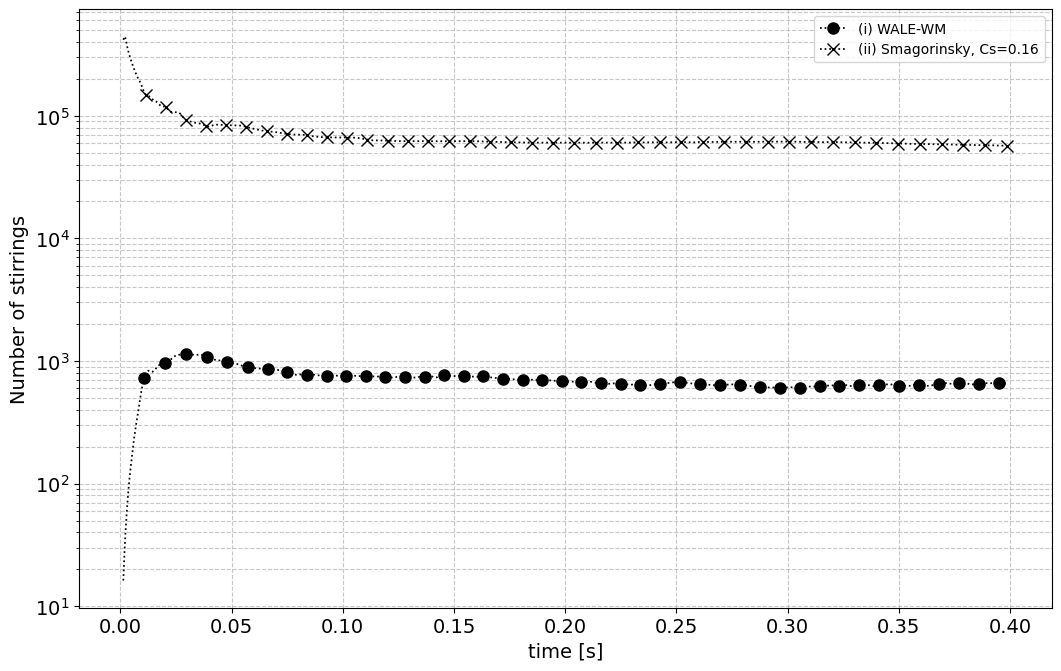

In [93]:
import sys

if AN not in sys.path:
    sys.path.insert(0, AN)
import stirring_from_log as sfl

STIR = [ ("(i) WALE-WM",    OUT + "/CLEM-WALE-WM/nonReactWaleWM.log", "black"),
        ("(ii) Smagorinsky, Cs=0.16", ROOT + "/NonReactSmagorisnky.log",        "black")]
COL = {n: i for i, n in enumerate(sfl.COLS)}


def roll(y, n=201):
    """Centred rolling mean with the ends blanked. mode='same' zero-pads, which
    drags the last n/2 points down and draws a cliff that reads as the stirring
    shutting off at the end of the run."""
    if len(y) < n:
        return y
    o = np.convolve(y, np.ones(n) / n, mode="same")
    o[:n // 2] = np.nan
    o[-(n // 2):] = np.nan
    return o


fig, ax = plt.subplots(1, 1, figsize=(10.5, 6.6), sharex=True,
                       constrained_layout=True)

# Set up markers and colors for each dataset
markers = ['o', 'x']  # Different markers for each case
markevery = 800  # Plot marker every 100th point

for idx, (lab, log, col) in enumerate(STIR):
    a = np.array(sfl.parse(log), dtype=float)
    t = a[:, COL["time"]] * 1e3
    drawn, applied = a[:, COL["drawn"]], a[:, COL["maps"]]
    
    # Plot with both line and markers
    ax.plot(t, roll(drawn), color=col, lw=1.25, linestyle = ":", 
            marker=markers[idx], markevery=markevery, 
            markersize=8, label=lab)

# Set y-axis to log scale
ax.set_yscale('log')

# Set x-axis to linear scale (this is default, but explicit for clarity)
ax.set_xscale('linear')

# Set tick parameters size to 14
ax.tick_params(axis='both', labelsize=14)

# Optional: Add grid for better readability with log scale
ax.grid(True, which='both', linestyle='--', alpha=0.7)

# Optional: Add legend
ax.legend()
ax.set_xlabel("time [s]", fontsize=14)
ax.set_ylabel("Number of stirrings", fontsize=14)

plt.savefig("NumberStirring.pdf")

# Show the plot
plt.show()

case                             t [ms]  RMS vs ref   max dev   [MPa]
(i) WALE + wall model             0.400     0.01749   0.03430
(ii) Smagorinsky, Cs=0.16         0.400     0.04575   0.08156
(iii) no SGS stress               not at 0.400 ms - SKIPPED


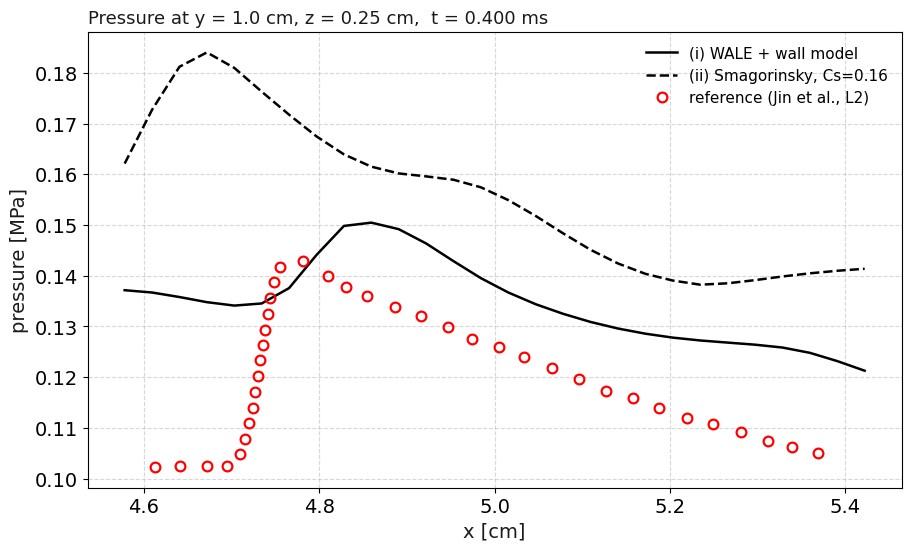

In [101]:
# ===== pressure profile: three closures against the L2 reference =============
# All curves BLACK, separated by LINE STYLE, not by marker: the reference owns
# "o", so markers on the solutions would blur the one distinction that matters.
# Reference = hollow RED circles, the only colour on the page.
#
# TPRESS is a real constraint, not a preference. The no-SGS case stopped at
# 0.180 ms, so 1.8e-4 is the LATEST instant all three share. Set it to 4.0e-4
# and that case drops out automatically (at_time returns None rather than
# quietly handing back its last file at the wrong instant).
TPRESS = 4.0e-4                               # s
YPROBE, ZPROBE, PSCALE = 1.0, 0.25, 1e-7      # pressure dyn/cm^2 -> MPa

# display label, plotfile glob, line style.  The glob lives here rather than
# being looked up in CASES by label, so these labels can be renamed freely.
PCASES = [("(i) WALE + wall model",     OUT + "/CLEM-WALE-WM/plt_nrWM*",   "-"),
          ("(ii) Smagorinsky, Cs=0.16", OUT + "/CLEM-Smagorinsky/plt_nrS*", "--"),
          ("(iii) no SGS stress",       ROOT + "/runs/01-nonreacting-CLEM/plt[0-9]*", "-.")]

xr = p_ref["x"].to_numpy() / 10.0             # reference x: mm -> cm
pr = p_ref["Pressure"].to_numpy()

fig, ax = plt.subplots(figsize=(9.0, 5.4), constrained_layout=True)

print(f"{'case':<30}{'t [ms]':>9}{'RMS vs ref':>12}{'max dev':>10}   [MPa]")
for lab, pat, ls in PCASES:
    t, path = at_time(pat, TPRESS)
    if path is None:
        print(f"{lab:<30}    not at {TPRESS*1e3:.3f} ms - SKIPPED")
        continue
    x, p = ray_x(yt.load(path), YPROBE, ZPROBE, "pressure", PSCALE)
    m = (x >= xr.min() - 0.05) & (x <= xr.max() + 0.05)
    ax.plot(x[m], p[m], ls, color="black", lw=1.8, label=lab)
    pi = np.interp(xr, x, p)                  # score at the reference stations
    print(f"{lab:<30}{t*1e3:9.3f}{np.sqrt(np.mean((pi - pr)**2)):12.5f}"
          f"{np.abs(pi - pr).max():10.5f}")

ax.plot(xr, pr, linestyle="", marker="o", ms=7, markevery=2,
        mfc="none", mec="red", mew=1.6, label="reference (Jin et al., L2)")

ax.set_xlabel("x [cm]", fontsize=14, color=INK)
ax.set_ylabel("pressure [MPa]", fontsize=14, color=INK)
ax.set_title(f"Pressure at y = {YPROBE} cm, z = {ZPROBE} cm,  "
             f"t = {TPRESS*1e3:.3f} ms", fontsize=13, color=INK, loc="left")
ax.tick_params(axis="both", labelsize=14)
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend(fontsize=11, frameon=False)

fig.savefig(f"{OUT}/compare_pressure_3closures_t{TPRESS*1e3:.2f}ms.pdf",
            bbox_inches="tight")
plt.show()


case                             t [ms]  RMS vs ref   max dev   [MPa]
(i) WALE + wall model             0.400     0.01749   0.03430
(ii) Smagorinsky, Cs=0.16         0.400     0.04575   0.08156
(iii) no SGS stress               0.180     0.01215   0.02776


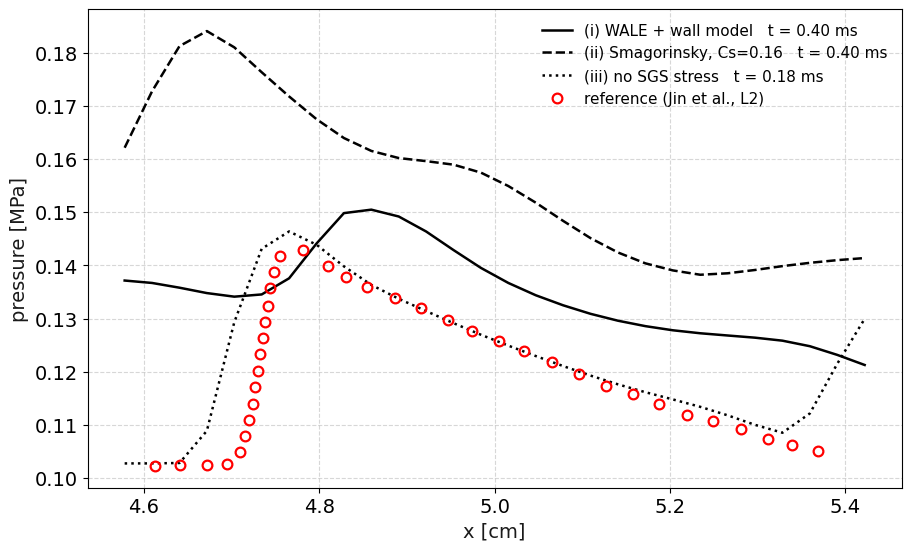

In [103]:
# ===== pressure profile: no-SGS at 0.18 ms vs the SGS models at 0.40 ms ======
# All curves BLACK, separated by LINE STYLE; reference = hollow RED circles.
# NOTE: the instants DIFFER by design - the no-SGS run stopped at 0.180 ms and
# is compared against the modelled runs at 0.400 ms. Each curve therefore
# carries its own t in the legend; do not read this as a same-instant figure.
YPROBE, ZPROBE, PSCALE = 1.0, 0.25, 1e-7      # pressure dyn/cm^2 -> MPa

# display label, plotfile glob, line style, target time [s]
PCASES = [("(i) WALE + wall model",     OUT + "/CLEM-WALE-WM/plt_nrWM*",    "-",  4.0e-4),
          ("(ii) Smagorinsky, Cs=0.16", OUT + "/CLEM-Smagorinsky/plt_nrS*", "--", 4.0e-4),
          ("(iii) no SGS stress",       ROOT + "/runs/01-nonreacting-CLEM/plt[0-9]*", ":", 1.8e-4)]

xr = p_ref["x"].to_numpy() / 10.0             # reference x: mm -> cm
pr = p_ref["Pressure"].to_numpy()

fig, ax = plt.subplots(figsize=(9.0, 5.4), constrained_layout=True)

print(f"{'case':<30}{'t [ms]':>9}{'RMS vs ref':>12}{'max dev':>10}   [MPa]")
for lab, pat, ls, ttarget in PCASES:
    t, path = at_time(pat, ttarget)
    if path is None:
        print(f"{lab:<30}    not at {ttarget*1e3:.3f} ms - SKIPPED")
        continue
    x, p = ray_x(yt.load(path), YPROBE, ZPROBE, "pressure", PSCALE)
    m = (x >= xr.min() - 0.05) & (x <= xr.max() + 0.05)
    ax.plot(x[m], p[m], ls, color="black", lw=1.8,
            label=f"{lab}   t = {t*1e3:.2f} ms")
    pi = np.interp(xr, x, p)                  # score at the reference stations
    print(f"{lab:<30}{t*1e3:9.3f}{np.sqrt(np.mean((pi - pr)**2)):12.5f}"
          f"{np.abs(pi - pr).max():10.5f}")

ax.plot(xr, pr, linestyle="", marker="o", ms=7, markevery=2,
        mfc="none", mec="red", mew=1.6, label="reference (Jin et al., L2)")

ax.set_xlabel("x [cm]", fontsize=14, color=INK)
ax.set_ylabel("pressure [MPa]", fontsize=14, color=INK)
ax.tick_params(axis="both", labelsize=14)
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend(fontsize=11, frameon=False)

fig.savefig(f"{OUT}/compare_pressure_nosgs0.18_vs_sgs0.40ms.pdf",
            bbox_inches="tight")
plt.show()
